# Cloud count oscillation bug

Cloud counts were oscillating way too much between timesteps. The tracked count would swing wildly even though the actual number of clouds identified by CloudField was fairly smooth. Turned out to be three bugs in the merge logic in `cloudtracker.py`, not a matching or threshold issue.

Test runs (6 timesteps each) saved in `output_archive/oscillation_fix_testing/`.

## The problem

Tracked count drops to 42 at t=1 when CloudField actually identifies 58 clouds. The tracker is losing clouds somewhere.

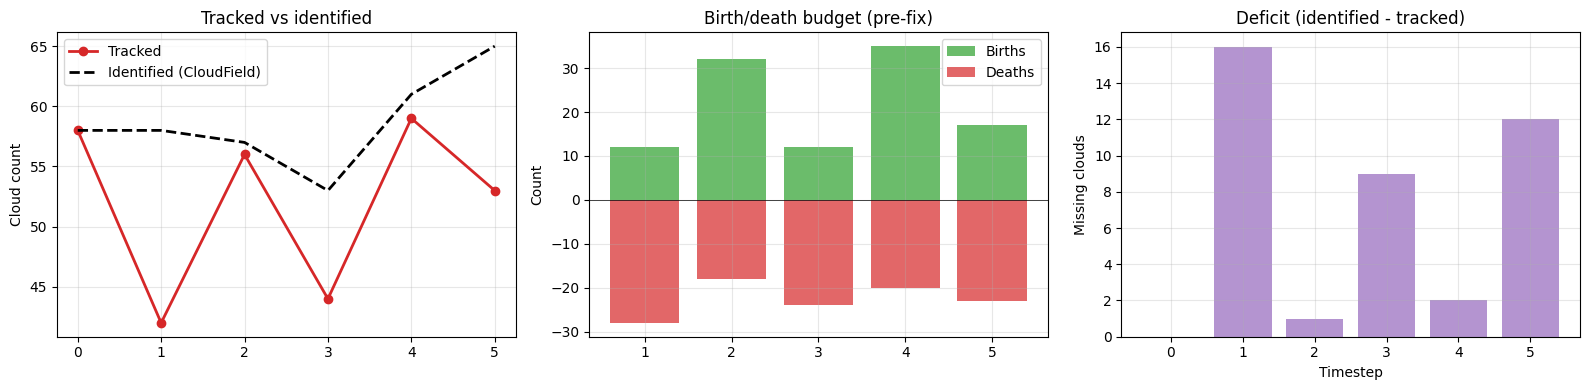

Tracked: [58, 42, 56, 44, 59, 53]
Identified: [58, 58, 57, 53, 61, 65]
Deficit: [0, 16, 1, 9, 2, 12]


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset

data_dir = '../output_archive/oscillation_fix_testing'
nc_path = f'{data_dir}/cloud_results_prefix_6ts.nc'

with Dataset(nc_path, 'r') as ds:
    size = np.asarray(np.ma.filled(ds.variables['size'][:], np.nan), dtype=float)
    split_from = np.asarray(np.ma.filled(ds.variables['split_from'][:], -1), dtype=int)
    merges_cnt = np.asarray(np.ma.filled(ds.variables['merges_count'][:], 0), dtype=int)

n_tracks, n_time = size.shape
alive = np.isfinite(size)
t_axis = np.arange(n_time)
alive_count = alive.sum(axis=0)

# these come from running CloudField identification independently
identified = np.array([58, 58, 57, 53, 61, 65])

births = np.zeros(n_time, dtype=int)
deaths = np.zeros(n_time, dtype=int)
for t in range(1, n_time):
    deaths[t] = (alive[:, t-1] & ~alive[:, t]).sum()
    births[t] = (~alive[:, t-1] & alive[:, t]).sum()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(t_axis, alive_count, 'o-', lw=2, color='tab:red', label='Tracked')
axes[0].plot(t_axis, identified, 'k--', lw=2, label='Identified (CloudField)')
axes[0].set_ylabel('Cloud count')
axes[0].set_title('Tracked vs identified')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(t_axis[1:], births[1:], color='tab:green', alpha=0.7, label='Births')
axes[1].bar(t_axis[1:], -deaths[1:], color='tab:red', alpha=0.7, label='Deaths')
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_title('Birth/death budget (pre-fix)')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

deficit = identified - alive_count
axes[2].bar(t_axis, deficit, color='tab:purple', alpha=0.7)
axes[2].axhline(0, color='k', lw=0.5)
axes[2].set_title('Deficit (identified - tracked)')
axes[2].set_ylabel('Missing clouds')
axes[2].set_xlabel('Timestep')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Tracked: {list(alive_count)}')
print(f'Identified: {list(identified)}')
print(f'Deficit: {list(deficit)}')

## What was investigated

Tested five theories before finding the actual cause:

1. **Threshold flickering** — clouds near the liquid water threshold pop in and out. Contributes to churn but doesn't explain the deficit between identified and tracked counts.
2. **Merge/split churning** — merges kill track IDs, splits create new ones. Merges correlated strongly with deaths, which pointed in the right direction.
3. **Identity loss** — the KD-tree overlap match fails and the cloud dies and is reborn as a new track. Found some cases but not the main driver.
4. **Small cloud turnover** — most dying clouds are small so the oscillation is just noise. True, but still doesn't explain the systematic deficit.
5. **Volume conservation** — total cloud volume is much smoother than count, confirming the count oscillation is a tracking artefact.

Also tried sensitivity experiments: increasing `match_shell_layers` (no change) and `match_safety_factor_dynamic` (made it worse). The matching parameters were not the problem.

The breakthrough was comparing CloudField identification counts (how many clouds actually exist in the labelled field) with the tracked alive counts. The deficit matched exactly the number of clouds swallowed by multi-merge events. The problem was in the merge logic.

## The three bugs

All three were in `update_tracks()` in `cloudtracker.py`.

### 1. Merge winner gets killed by the regular match loop

When a cloud merges into a track, the merged cloud gets added to `new_matched_clouds`. Then the regular match loop goes through that same track, can't find any unmatched child (because the cloud is already matched), and kills the track. So the track that just won a merge immediately dies.

Fix: skip tracks that already have a cloud from the current timestep.
```python
if last_cloud_in_track.timestep == current_cloud_field.timestep:
    continue
```

Post-merge death rate went from 93% to 21%.

### 2. One track wins multiple merges at the same timestep

Nothing was stopping a single track from winning multiple merges in the same timestep. Each merge appends a cloud to the track list, but only `track[-1]` gets used for matching at the next step. The earlier appended clouds are effectively orphaned — their continuations show up as spurious new births.

Fix: use a `committed_tracks` set so each track can only win one merge per timestep. If a track is already committed, the merge falls through to the next-best parent.

After this fix, tracked count = identified count at every timestep. The deficit went to zero.

### 3. Merge losers killed too early

When a track loses a merge (another track wins the shared cloud), the loser was immediately killed. But the loser might have other children at the same timestep — a cloud that split off. Killing the loser right away meant that split was never detected, and the child showed up as a brand new birth instead.

Fix: don't kill merge losers in the merge pass. Just record `merged_into` and let the regular match loop handle death. Also count all children per track in split detection (not just single-parent ones).

Result: more splits correctly detected, fewer spurious births, longer mean lifetimes.

## Comparison across fixes

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset

data_dir = '../output_archive/oscillation_fix_testing'
files = {
    'Pre-fix': f'{data_dir}/cloud_results_prefix_6ts.nc',
    'Fix1 (winner guard)': f'{data_dir}/cloud_results_postfix_6ts.nc',
    'Fix2 (constrained)': f'{data_dir}/cloud_results_postfix2_6ts.nc',
    'Fix3 (loser survival)': f'{data_dir}/cloud_results_postfix3_6ts.nc',
}
identified = np.array([58, 58, 57, 53, 61, 65])
colors = {'Pre-fix': 'red', 'Fix1 (winner guard)': 'orange',
          'Fix2 (constrained)': '#aabb00', 'Fix3 (loser survival)': 'green'}

results = {}
for label, path in files.items():
    ds = Dataset(path, 'r')
    sz = np.asarray(np.ma.filled(ds.variables['size'][:], np.nan), dtype=float)
    mg = np.asarray(np.ma.filled(ds.variables['merges_count'][:], 0), dtype=int)
    sp = np.asarray(np.ma.filled(ds.variables['splits_count'][:], 0), dtype=int)
    sf = np.asarray(np.ma.filled(ds.variables['split_from'][:], -1), dtype=int)
    alive = np.isfinite(sz)
    n_tr, n_t = sz.shape
    alive_count = alive.sum(axis=0)

    deaths = np.zeros(n_t, dtype=int)
    births = np.zeros(n_t, dtype=int)
    merges_per_t = np.zeros(n_t, dtype=int)
    splits_per_t = np.zeros(n_t, dtype=int)
    births_new = np.zeros(n_t, dtype=int)
    births_split = np.zeros(n_t, dtype=int)
    for ti in range(1, n_t):
        deaths[ti] = (alive[:, ti-1] & ~alive[:, ti]).sum()
        born_mask = (~alive[:, ti-1]) & alive[:, ti]
        births[ti] = born_mask.sum()
        births_split[ti] = (born_mask & (sf[:, ti] >= 0)).sum()
        births_new[ti] = (born_mask & (sf[:, ti] < 0)).sum()
        merges_per_t[ti] = (mg[:, ti] > 0).sum()
        splits_per_t[ti] = (sp[:, ti] > 0).sum()

    vol = np.nansum(sz, axis=0)
    lt = np.zeros(n_tr)
    for i in range(n_tr):
        lt[i] = alive[i].sum()
    lt = lt[lt > 0]

    results[label] = {
        'alive': alive_count, 'deaths': deaths, 'births': births,
        'births_new': births_new, 'births_split': births_split,
        'volume': vol, 'merges': merges_per_t, 'splits': splits_per_t,
        'n_t': n_t, 'lifetime': lt,
    }
    ds.close()

print(f"{'Metric':<30s} {'Pre-fix':>8s} {'Fix1':>8s} {'Fix2':>8s} {'Fix3':>8s} {'Ident.':>8s}")
print("-" * 75)
for ti in range(6):
    vals = [results[l]['alive'][ti] for l in files]
    ident = identified[ti]
    print(f"  t={ti} alive                    {vals[0]:8d} {vals[1]:8d} {vals[2]:8d} {vals[3]:8d} {ident:8d}")

print()
for label in files:
    r = results[label]
    a = r['alive']
    amp = a.max() - a.min()
    cv = np.std(a) / np.mean(a)
    td = r['deaths'][1:].sum()
    tb = r['births'][1:].sum()
    tb_new = r['births_new'][1:].sum()
    tb_split = r['births_split'][1:].sum()
    ts = r['splits'][1:].sum()
    mean_lt = np.mean(r['lifetime'])
    print(f"{label}:")
    print(f"  Amp={amp}, CV={cv:.3f}, Deaths={td}, Births={tb} (new={tb_new}, split={tb_split}), Splits={ts}, Mean LT={mean_lt:.2f}")

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
t_ax = np.arange(6)

for label, r in results.items():
    axes[0, 0].plot(t_ax, r['alive'], 'o-', color=colors[label], label=label, markersize=5)
axes[0, 0].plot(t_ax, identified, 'k--', label='Identified', linewidth=2)
axes[0, 0].set_title('Cloud count'); axes[0, 0].set_ylabel('Count')
axes[0, 0].legend(fontsize=7)

for label, r in results.items():
    axes[0, 1].plot(t_ax[1:], r['deaths'][1:], 'o-', color=colors[label], markersize=5)
axes[0, 1].set_title('Deaths per timestep'); axes[0, 1].set_ylabel('Deaths')

for label, r in results.items():
    axes[0, 2].plot(t_ax[1:], r['births'][1:], 'o-', color=colors[label], markersize=5)
axes[0, 2].set_title('Births per timestep'); axes[0, 2].set_ylabel('Births')

for label, r in results.items():
    axes[1, 0].plot(t_ax[1:], r['births_new'][1:], 'o-', color=colors[label], markersize=5)
axes[1, 0].set_title('New births (not from split)'); axes[1, 0].set_ylabel('New births')
axes[1, 0].set_xlabel('Timestep')

for label, r in results.items():
    axes[1, 1].plot(t_ax[1:], r['splits'][1:], 'o-', color=colors[label], markersize=5)
axes[1, 1].set_title('Splits per timestep'); axes[1, 1].set_ylabel('Splits')
axes[1, 1].set_xlabel('Timestep')

for label in ['Fix2 (constrained)', 'Fix3 (loser survival)']:
    lt = results[label]['lifetime']
    bins = np.arange(1, lt.max() + 2) - 0.5
    axes[1, 2].hist(lt, bins=bins, alpha=0.5, color=colors[label], label=label, edgecolor='black')
axes[1, 2].set_title('Track lifetime distribution'); axes[1, 2].set_xlabel('Lifetime (timesteps)')
axes[1, 2].set_ylabel('Count'); axes[1, 2].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Outcome

After fix 2, tracked count matches CloudField identification at every timestep. The remaining count variation is real physical variability in the cloud field, not a tracking artefact.

Fix 3 doesn't change cloud counts but improves track continuity: fewer spurious deaths and births, more splits correctly attributed, longer mean lifetimes.

All three fixes are in `lib/cloudtracker.py`, branch `fix_oscillation`.